<a href="https://colab.research.google.com/github/sandip-1996/PRML_exercise_code_example/blob/Probability-distribution-ch.-2/student_t_distribution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

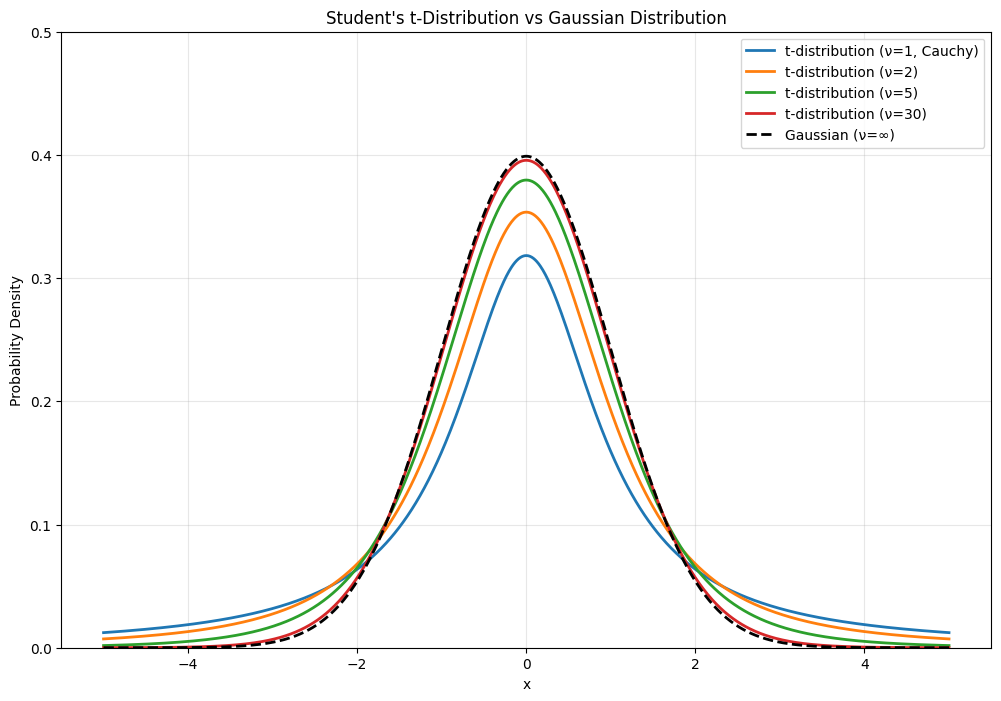

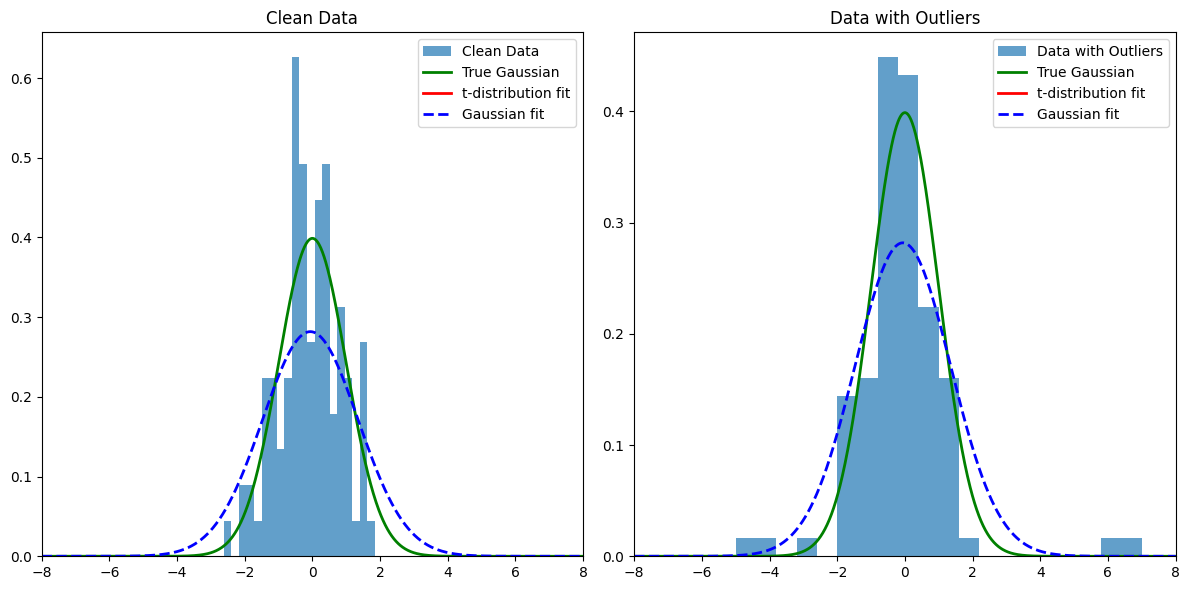

Gaussian fit - Mean: -0.061, Std: 1.415
t-distribution fit - Location: 2.621, Scale: -0.090, DoF: 0.76
Student's t-Distribution Properties

Degrees of freedom (ν): 1
Mean: nan
Variance: nan

Degrees of freedom (ν): 2
Mean: 0
Variance: inf
Empirical Mean: 0.041
Empirical Variance: 14.210

Degrees of freedom (ν): 5
Mean: 0
Variance: 1.6666666666666667
Empirical Mean: -0.000
Empirical Variance: 1.682

Degrees of freedom (ν): 10
Mean: 0
Variance: 1.25
Empirical Mean: -0.000
Empirical Variance: 1.250

Degrees of freedom (ν): 30
Mean: 0
Variance: 1.0714285714285714
Empirical Mean: -0.014
Empirical Variance: 1.082

Multivariate t-Distribution Example


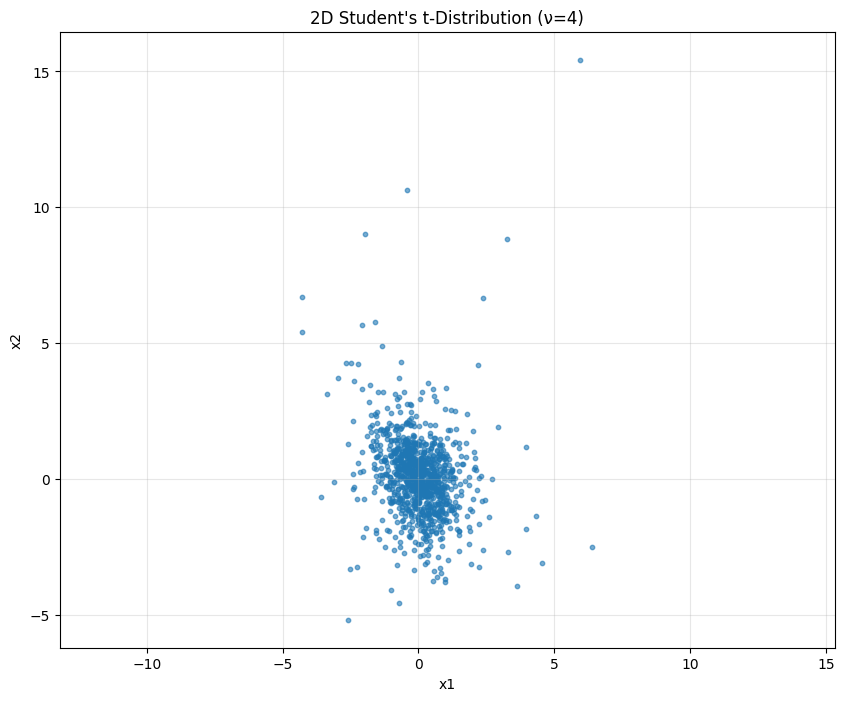

Theoretical mean: [0 0]
Sample mean: [0.00984896 0.0971365 ]
Theoretical covariance (for ν>2): [[ 1.14285714 -0.57142857]
 [-0.57142857  2.28571429]]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

class StudentTDistribution:
    """
    Simple implementation of Student's t-distribution
    """

    def __init__(self, mu=0, lambda_param=1, nu=1):
        """
        Parameters:
        mu: location parameter (mean for nu > 1)
        lambda_param: precision parameter (not inverse variance!)
        nu: degrees of freedom
        """
        self.mu = mu
        self.lambda_param = lambda_param
        self.nu = nu
        self.scale = 1 / np.sqrt(lambda_param * nu / (nu - 2)) if nu > 2 else 1 / np.sqrt(lambda_param)

    def pdf(self, x):
        """Probability density function"""
        # Using scipy's t-distribution with proper scaling
        # scipy uses: location = mu, scale = 1/sqrt(lambda * nu/(nu-2)) for nu>2
        scale = 1 / np.sqrt(self.lambda_param)
        return stats.t.pdf(x, df=self.nu, loc=self.mu, scale=scale)

    def mean(self):
        """Mean of the distribution"""
        return self.mu if self.nu > 1 else np.nan

    def variance(self):
        """Variance of the distribution"""
        if self.nu > 2:
            return self.nu / (self.nu - 2) * (1 / self.lambda_param)
        elif self.nu > 1:
            return np.inf  # Variance is infinite for 1 < nu <= 2
        else:
            return np.nan  # Mean doesn't exist

    def generate_samples(self, n_samples=1000):
        """Generate random samples from the distribution"""
        scale = 1 / np.sqrt(self.lambda_param)
        return stats.t.rvs(df=self.nu, loc=self.mu, scale=scale, size=n_samples)

def compare_with_gaussian():
    """Compare t-distribution with Gaussian distribution"""
    x = np.linspace(-5, 5, 1000)

    # Create different t-distributions
    t_nu1 = StudentTDistribution(mu=0, lambda_param=1, nu=1)  # Cauchy
    t_nu2 = StudentTDistribution(mu=0, lambda_param=1, nu=2)
    t_nu5 = StudentTDistribution(mu=0, lambda_param=1, nu=5)
    t_nu30 = StudentTDistribution(mu=0, lambda_param=1, nu=30)  # Close to Gaussian

    # Gaussian with same mean and "equivalent" precision
    gaussian = stats.norm(loc=0, scale=1/np.sqrt(1))

    plt.figure(figsize=(12, 8))

    # Plot PDFs
    plt.plot(x, t_nu1.pdf(x), label=f't-distribution (ν=1, Cauchy)', linewidth=2)
    plt.plot(x, t_nu2.pdf(x), label=f't-distribution (ν=2)', linewidth=2)
    plt.plot(x, t_nu5.pdf(x), label=f't-distribution (ν=5)', linewidth=2)
    plt.plot(x, t_nu30.pdf(x), label=f't-distribution (ν=30)', linewidth=2)
    plt.plot(x, gaussian.pdf(x), 'k--', label='Gaussian (ν=∞)', linewidth=2)

    plt.xlabel('x')
    plt.ylabel('Probability Density')
    plt.title('Student\'s t-Distribution vs Gaussian Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 0.5)
    plt.show()

def demonstrate_robustness():
    """Demonstrate robustness of t-distribution to outliers"""
    np.random.seed(42)

    # Generate clean data from Gaussian
    clean_data = np.random.normal(0, 1, 100)

    # Add outliers
    outliers = np.array([-5, -4, 6, 7])
    contaminated_data = np.concatenate([clean_data, outliers])

    # Fit distributions
    # For Gaussian: MLE is just sample mean and variance
    gaussian_mu = np.mean(contaminated_data)
    gaussian_sigma = np.std(contaminated_data)

    # For t-distribution: use scipy's fit (simplified)
    t_params = stats.t.fit(contaminated_data)
    t_mu, t_sigma, t_nu = t_params

    # Plot results
    x = np.linspace(-8, 8, 1000)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.hist(clean_data, bins=20, density=True, alpha=0.7, label='Clean Data')
    plt.plot(x, stats.norm.pdf(x, 0, 1), 'g-', label='True Gaussian', linewidth=2)
    plt.plot(x, stats.t.pdf(x, t_nu, t_mu, t_sigma), 'r-', label='t-distribution fit', linewidth=2)
    plt.plot(x, stats.norm.pdf(x, gaussian_mu, gaussian_sigma), 'b--', label='Gaussian fit', linewidth=2)
    plt.title('Clean Data')
    plt.legend()
    plt.xlim(-8, 8)

    plt.subplot(1, 2, 2)
    plt.hist(contaminated_data, bins=20, density=True, alpha=0.7, label='Data with Outliers')
    plt.plot(x, stats.norm.pdf(x, 0, 1), 'g-', label='True Gaussian', linewidth=2)
    plt.plot(x, stats.t.pdf(x, t_nu, t_mu, t_sigma), 'r-', label='t-distribution fit', linewidth=2)
    plt.plot(x, stats.norm.pdf(x, gaussian_mu, gaussian_sigma), 'b--', label='Gaussian fit', linewidth=2)
    plt.title('Data with Outliers')
    plt.legend()
    plt.xlim(-8, 8)

    plt.tight_layout()
    plt.show()

    print(f"Gaussian fit - Mean: {gaussian_mu:.3f}, Std: {gaussian_sigma:.3f}")
    print(f"t-distribution fit - Location: {t_mu:.3f}, Scale: {t_sigma:.3f}, DoF: {t_nu:.2f}")

def basic_properties():
    """Show basic properties of t-distribution"""
    print("Student's t-Distribution Properties")
    print("=" * 50)

    # Test different degrees of freedom
    for nu in [1, 2, 5, 10, 30]:
        t_dist = StudentTDistribution(mu=0, lambda_param=1, nu=nu)

        print(f"\nDegrees of freedom (ν): {nu}")
        print(f"Mean: {t_dist.mean()}")
        print(f"Variance: {t_dist.variance()}")

        if nu > 1:
            samples = t_dist.generate_samples(10000)
            empirical_mean = np.mean(samples)
            empirical_var = np.var(samples)
            print(f"Empirical Mean: {empirical_mean:.3f}")
            print(f"Empirical Variance: {empirical_var:.3f}")

def multivariate_t_example():
    """Simple example of multivariate t-distribution"""
    print("\nMultivariate t-Distribution Example")
    print("=" * 50)

    # Parameters for 2D t-distribution
    mu = np.array([0, 0])  # location
    Lambda = np.array([[2, 0.5],  # precision matrix
                      [0.5, 1]])
    nu = 4  # degrees of freedom

    # Generate samples using the mixture representation
    n_samples = 1000
    eta = stats.gamma.rvs(nu/2, scale=2/nu, size=n_samples)  # Sample from Gamma(nu/2, nu/2)

    # For each eta, sample from Gaussian with scaled precision
    samples = []
    for i in range(n_samples):
        # Covariance matrix for this sample is (eta * Lambda)^{-1}
        cov_matrix = np.linalg.inv(eta[i] * Lambda)
        sample = np.random.multivariate_normal(mu, cov_matrix)
        samples.append(sample)

    samples = np.array(samples)

    # Plot
    plt.figure(figsize=(10, 8))
    plt.scatter(samples[:, 0], samples[:, 1], alpha=0.6, s=10)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(f'2D Student\'s t-Distribution (ν={nu})')
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.show()

    print(f"Theoretical mean: {mu}")
    print(f"Sample mean: {np.mean(samples, axis=0)}")
    print(f"Theoretical covariance (for ν>2): {np.linalg.inv(Lambda) * nu/(nu-2)}")

if __name__ == "__main__":
    # Run demonstrations
    compare_with_gaussian()
    demonstrate_robustness()
    basic_properties()
    multivariate_t_example()